In [3]:
import pandas as pd
import numpy as np

#visualize
import matplotlib.pyplot as plt
import seaborn as sns

#sckitlearn mengelola model
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('../Dataset/housing_dataset_synthetic.csv')
df.head(5)


,median_income_10k,house_age_years,avg_rooms,avg_bedrooms,population,latitude,longitude,median_house_value
0,5.931,17,4.77,3.81,4385,38.0192,-124.4177,232200.0
1,14.285,9,4.78,2.31,469,40.9252,-117.8753,728600.0
2,11.114,33,7.90,5.75,2296,36.4338,-119.7994,540700.0
3,9.181,20,5.62,3.87,3847,38.0709,-123.0901,433400.0
4,2.762,13,3.80,1.91,751,38.3131,-114.4417,181000.0


# feature dan target

In [4]:
# Feature dan target
X = df.drop(columns=['median_house_value'])  # fitur
y = df['median_house_value']  # target

# train test split


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
X_train.shape, X_test.shape


((400, 7), (100, 7))

# Scalling fiture numnjerik

In [6]:
scaler = StandardScaler() #membuat objek scaller

#fit belajar dari data training
#transofrm mengfubah data
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Training model 

In [7]:
# Latih model dengan regresi linear

lin_reg = LinearRegression()

## latihan model

lin_reg.fit(X_train_scaled, y_train)

#prediksi data training
#untuk melihat seberapa baik model mnenghafal data yg dipelajari
y_train_pred = lin_reg.predict(X_train_scaled)

#prediksi data testing
#untuk melihat kemampuan model pd data baru
y_test_pred = lin_reg.predict(X_test_scaled)

In [8]:
pd.DataFrame({
    'Actual' : y_test,
    'Predicted' : y_test_pred
}).head()

,Actual,Predicted
361,459600.0,478884.639509
73,568600.0,576660.628474
374,72600.0,78616.569420
155,215300.0,223012.669411
104,652700.0,655807.377201


## Visualize

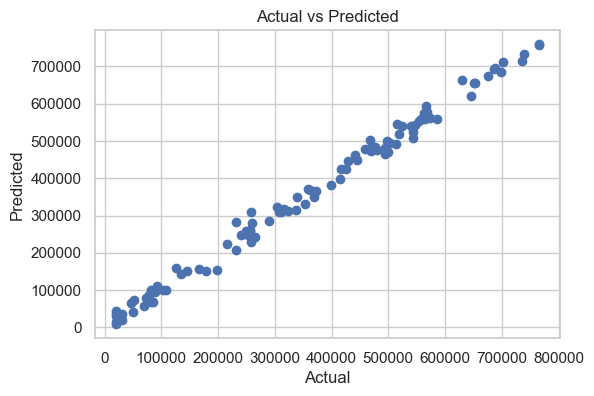

In [9]:
sns.set(style='whitegrid', context='notebook')
plt.rcParams["figure.figsize"] = (6,4)

plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

### interprertasi koeefiesien

memahami pengaruh fitur ke hasil prediksi

In [10]:
scaler = StandardScaler()  # membuat objek scaler

# Fit belajar dari data training lalu transform
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Mengambil nilai koefisien dan intercept
coef = lin_reg.coef_        # gunakan coef_ dengan underscore
intercept = lin_reg.intercept_

# Nama fitur
feat_names = X_train.columns

# DataFrame koefisien
coef_df = pd.DataFrame({
    'Feature': feat_names,
    'Coefficient': coef
}).sort_values('Coefficient', ascending=False)

print('Koefisien setiap fitur:\n', coef_df)
print('Intercept : ', intercept)


Koefisien setiap fitur:
              Feature    Coefficient
0  median_income_10k  216422.981493
2          avg_rooms    8201.860671
5           latitude     701.055197
6          longitude     632.652823
3       avg_bedrooms   -3099.285066
4         population   -5629.952372
1    house_age_years  -16434.658869
Intercept :  380350.75


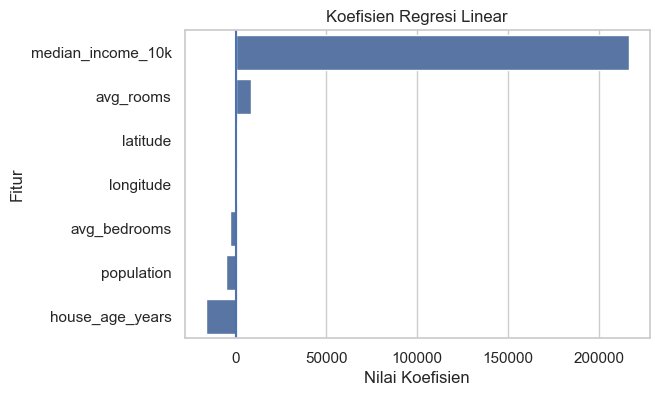

In [11]:
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coef_df,
    orient='h'
)
plt.title('Koefisien Regresi Linear')
plt.xlabel('Nilai Koefisien')
plt.ylabel('Fitur')

plt.axvline(5)
plt.show()    

In [12]:
## metrik evaluasi regresi
# adalah matriks yang digunakan untuk mengukur seberapa baik model regresi dalam memprediksi
#  nilai target. Beberapa metrik evaluasi regresi yang umum digunakan antara lain:
##mse + mae + r2 score
# mse = mean_squared_error(y_test, y_test_pred)
# mae = mean_absolute_error(y_test, y_test_pred)
# r2 = r2_score(y_test, y_test_pred)

In [13]:
from unicodedata import name


def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print (f'[{name}]')
    print('MSE : ', mse)
    print('RMSE : ', rmse)
    print('MAE : ', mae)
    print('R^2 : ', r2)
    

In [ ]:
## hitung matyriks testn dan 

#train
regression_metrics(y_train, y_train_pred, name='Linear regression - Train')
#Test
regression_metrics(y_test, y_test_pred, name='Linear regression - Test')



NameError: name 'regression_metrics' is not defined